# Access to CAMS EAC4 ARCO dataset

**References**
- ARCO catalogue: https://arco-stac.datastores.ecmwf.int/?.language=en
- ARCO User Guide: https://confluence.ecmwf.int/display/CDSM/ARCO+S3+AAA+Proxy+-+User+documentation

### Common Python imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import xarray as xr
import yaml

The ARCO service uses the ADS/CDS authentication token, you can also copy it manually

In [2]:
HOME = Path.home()
with open(HOME / ".cdsapirc") as f:
   cdsrc = yaml.safe_load(f)
   TOKEN = cdsrc['key']
# or copy it here from your account or your CDS API configuration file
# TOKEN = "xxxxxx-xxxxxx-xxxxxx-xxxxxx"

## CAMS atmospheric composition reanalysis EAC4

In [11]:
ARCO_ENDPOINT="https://arco.datastores.ecmwf.int"
DATASET = "cams_global_reanalysis_eac4"

### The dataset optimised for field extraction

In [7]:
BUCKET = "cadl-arco-time-010"
ITEM = "sfc"
DATACUBE = "timeChunked.zarr"

url = f"{ARCO_ENDPOINT}/{BUCKET}/arco/{DATASET}/{ITEM}/{DATACUBE}"
print(url)
ds = xr.open_zarr(
   url, consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {TOKEN}"}
    }
)

print(ds)

https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cams_global_reanalysis_eac4/sfc/timeChunked.zarr
<xarray.Dataset> Size: 398GB
Dimensions:    (time: 66232, latitude: 241, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 530kB 2003-01-01 ... 2025-08-31T21:00:00
  * latitude   (latitude) float64 2kB -90.0 -89.25 -88.5 ... 88.5 89.25 90.0
  * longitude  (longitude) float64 4kB -180.0 -179.2 -178.5 ... 178.5 179.2
Data variables: (12/13)
    aod550     (time, latitude, longitude) float32 31GB dask.array<chunksize=(8, 241, 480), meta=np.ndarray>
    bcaod550   (time, latitude, longitude) float32 31GB dask.array<chunksize=(8, 241, 480), meta=np.ndarray>
    duaod550   (time, latitude, longitude) float32 31GB dask.array<chunksize=(8, 241, 480), meta=np.ndarray>
    gtco3      (time, latitude, longitude) float32 31GB dask.array<chunksize=(8, 241, 480), meta=np.ndarray>
    omaod550   (time, latitude, longitude) float32 31GB dask.array<chunksize=(8, 241, 480), meta=np.

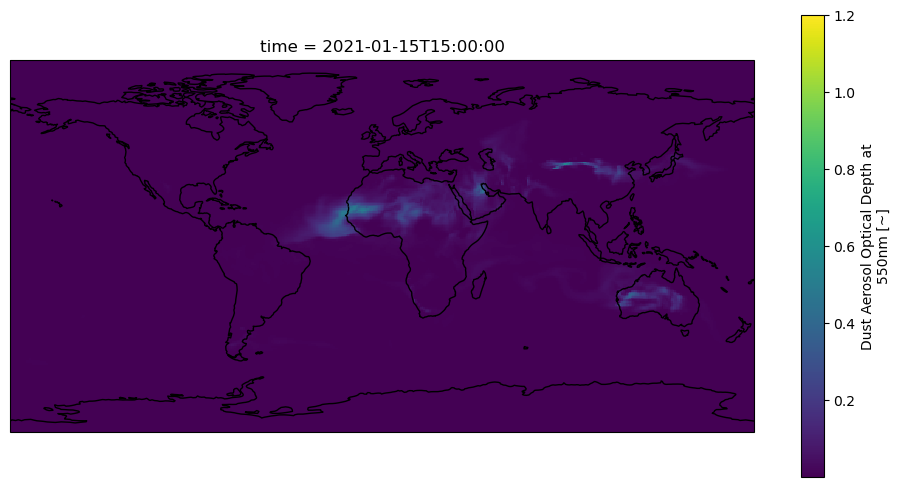

In [10]:
import datetime
import cartopy.crs as ccrs

dt = datetime.datetime(2021,1,15,15).strftime("%Y-%m-%dT%H:00:00")
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds.duaod550.sel(time=dt).plot(vmax=1.2)
ax.coastlines()